In [22]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from vtools import plot as vplt

import uncertainties as un
import uncertainties.unumpy as unp
from uncertainties.unumpy import nominal_values as nom
from uncertainties.unumpy import std_devs as std
from scipy import stats, optimize

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Data

In [2]:
dat = pd.read_pickle('data/vaterite_processed.pkl')

no_high_mg = (dat.solution_start['Mg/Ca'] < 3).values  # exclude high Mg point that grew aragonite
vaterite_growth = dat.overgrowth.F_V.values >= 0  # only select data where vaterite grew


## Physical Characterstics

### How does the amount of new growth change with solution chemistry?

/tmp/ipykernel_13107/119906347.py:5: MatplotlibDeprecationWarning: The join function was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  ax.get_shared_y_axes().join(ax, axs[0])


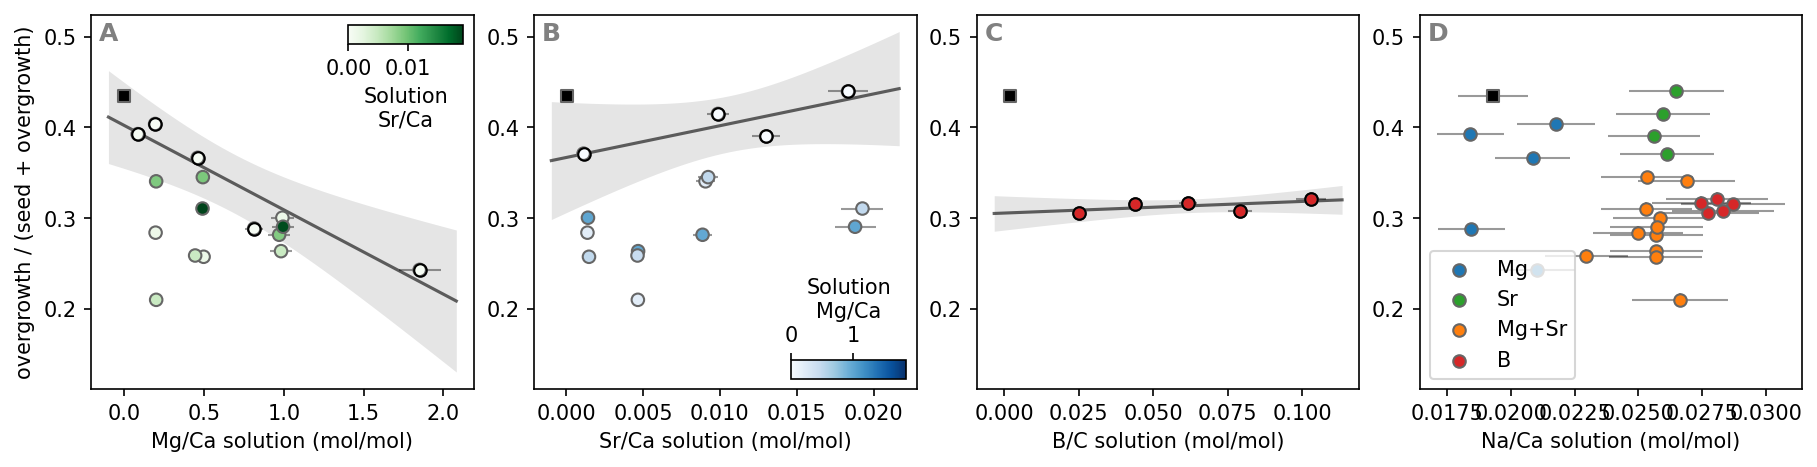

In [7]:
yvar=('derived', 'f')

fig, axs = vplt.solution_vs_yvar(dat.loc[no_high_mg & vaterite_growth], yvar=yvar)
for ax in axs[1:]:
    ax.get_shared_y_axes().join(ax, axs[0])
    ax.set_ylabel(None)
axs[0].set_ylabel('overgrowth / (seed + overgrowth)')

# line of best fit for single-element experiments
for i, el in enumerate(['Mg', 'Sr', 'B']):
    denom = 'Ca'
    if el == 'B':
        denom = 'C'
    ax = axs[i]
    sub = dat.loc[no_high_mg & vaterite_growth & (dat.metadata.Experiment.isin([el]).values)]
    x = nom(sub.solution_start[f'{el}/{denom}']).ravel()
    y = nom(sub[yvar]).ravel()
    
    ax.scatter(x, y, color=(0,0,0,0), edgecolor='k', lw=1)
    p, cov = np.polyfit(x, y, 1, cov=True)
    up = un.correlated_values(p, cov)
    nx = np.linspace(*ax.get_xlim())
    pred = np.polyval(up, nx)
    ci_m = stats.t.interval(0.95, len(x) - 1)
    ax.plot(nx, nom(pred), color='k', alpha=0.6, zorder=-5)
    ax.fill_between(nx, nom(pred) + std(pred) * ci_m[0], nom(pred) + std(pred) * ci_m[1], alpha=0.1, color='k', lw=0, zorder=-5)
    
vplt.label_axes(axs)

fig.savefig('figs/Fig5.pdf')

### How does the amount of vaterite in the overgrowth change with solution chemistry?

/tmp/ipykernel_13107/221264889.py:4: MatplotlibDeprecationWarning: The join function was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  ax.get_shared_y_axes().join(ax, axs[0])


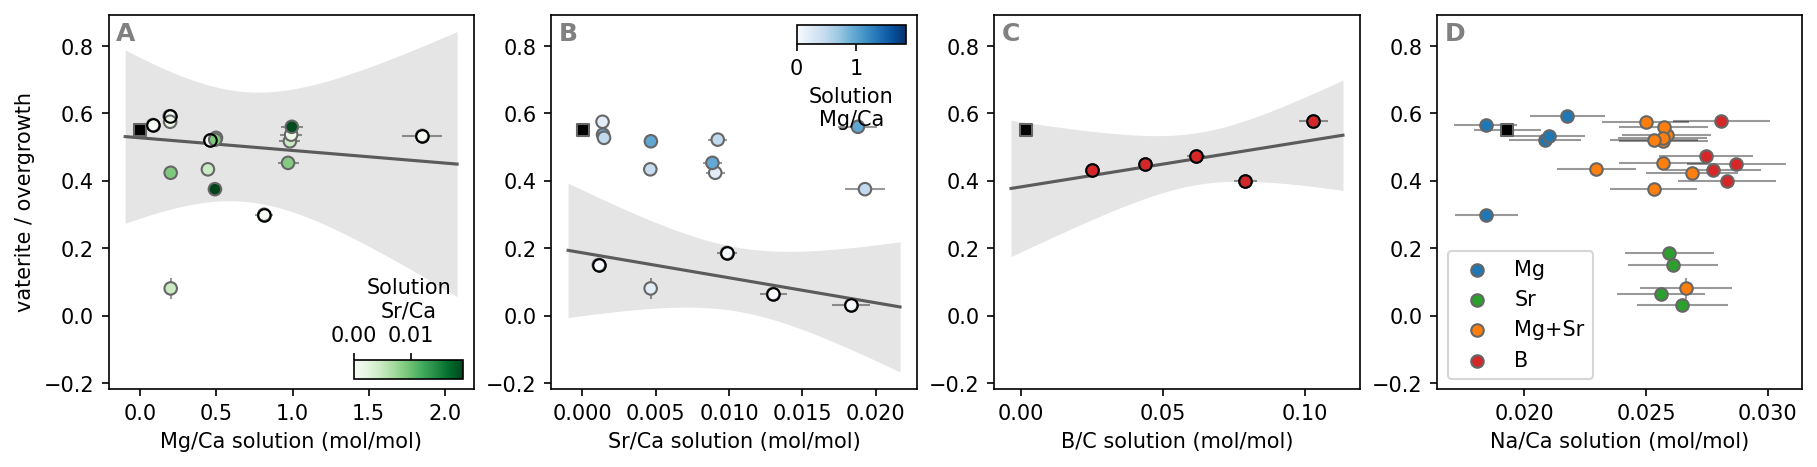

In [8]:
yvar=('overgrowth', 'F_V')
fig, axs = vplt.solution_vs_yvar(dat.loc[no_high_mg & vaterite_growth], yvar=yvar)
for ax in axs[1:]:
    ax.get_shared_y_axes().join(ax, axs[0])
    ax.set_ylabel(None)
axs[0].set_ylabel('vaterite / overgrowth');

# line of best fit for single-element experiments
for i, el in enumerate(['Mg', 'Sr', 'B']):
    denom = 'Ca'
    if el == 'B':
        denom = 'C'
    ax = axs[i]
    sub = dat.loc[no_high_mg & vaterite_growth & (dat.metadata.Experiment.isin([el]).values)]
    x = nom(sub.solution_start[f'{el}/{denom}']).ravel()
    y = nom(sub[yvar]).ravel()
    
    ax.scatter(x, y, color=(0,0,0,0), edgecolor='k', lw=1)
    p, cov = np.polyfit(x, y, 1, cov=True)
    up = un.correlated_values(p, cov)
    nx = np.linspace(*ax.get_xlim())
    pred = np.polyval(up, nx)
    ci_m = stats.t.interval(0.95, len(x) - 1)
    ax.plot(nx, nom(pred), color='k', alpha=0.6, zorder=-5)
    ax.fill_between(nx, nom(pred) + std(pred) * ci_m[0], nom(pred) + std(pred) * ci_m[1], alpha=0.1, color='k', lw=0, zorder=-5)
    
vplt.label_axes(axs)

fig.savefig('figs/Fig7.pdf')

(-0.05, 1.05)

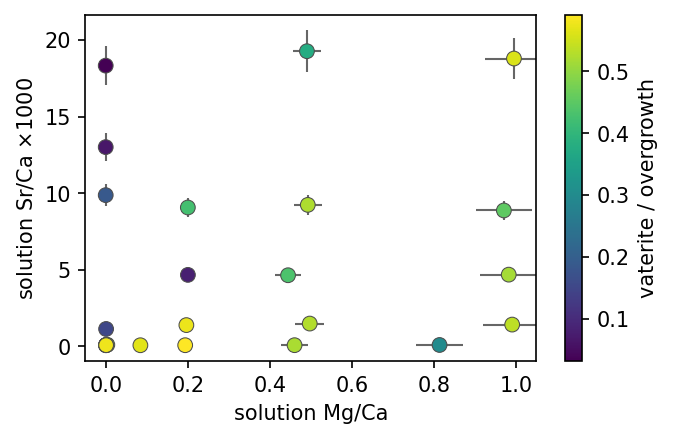

In [9]:
fig, ax = plt.subplots(1,1)

ma = ax.scatter(
    x=nom(dat.loc[no_high_mg & vaterite_growth, ('solution_start', 'Mg/Ca')]), 
    y=nom(dat.loc[no_high_mg & vaterite_growth, ('solution_start', 'Sr/Ca')]) * 1e3,
    c=nom(dat.loc[no_high_mg & vaterite_growth, ('overgrowth', 'F_V')]),
    s=50, lw=0.5, edgecolors=(.3, .3, .3)
)

ax.errorbar(
    x=nom(dat.loc[no_high_mg & vaterite_growth, ('solution_start', 'Mg/Ca')].values.ravel()), 
    xerr=std(dat.loc[no_high_mg & vaterite_growth, ('solution_start', 'Mg/Ca')].values.ravel()), 
    y=nom(dat.loc[no_high_mg & vaterite_growth, ('solution_start', 'Sr/Ca')].values.ravel()) * 1e3,
    yerr=std(dat.loc[no_high_mg & vaterite_growth, ('solution_start', 'Sr/Ca')].values.ravel()) * 1e3,
    lw=0, elinewidth=1, color=(0,0,0,0.6), zorder=-2
)

plt.colorbar(ma, ax=ax, label='vaterite / overgrowth')

ax.set_xlabel('solution Mg/Ca')
ax.set_ylabel('solution Sr/Ca $\\times 1000$')

ax.set_xlim(-0.05, 1.05)

## Overgrowth Composition

### Overgrowth composition as a function of solution chemistry

/usr/lib/python3.10/site-packages/matplotlib/axes/_base.py:2539: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)


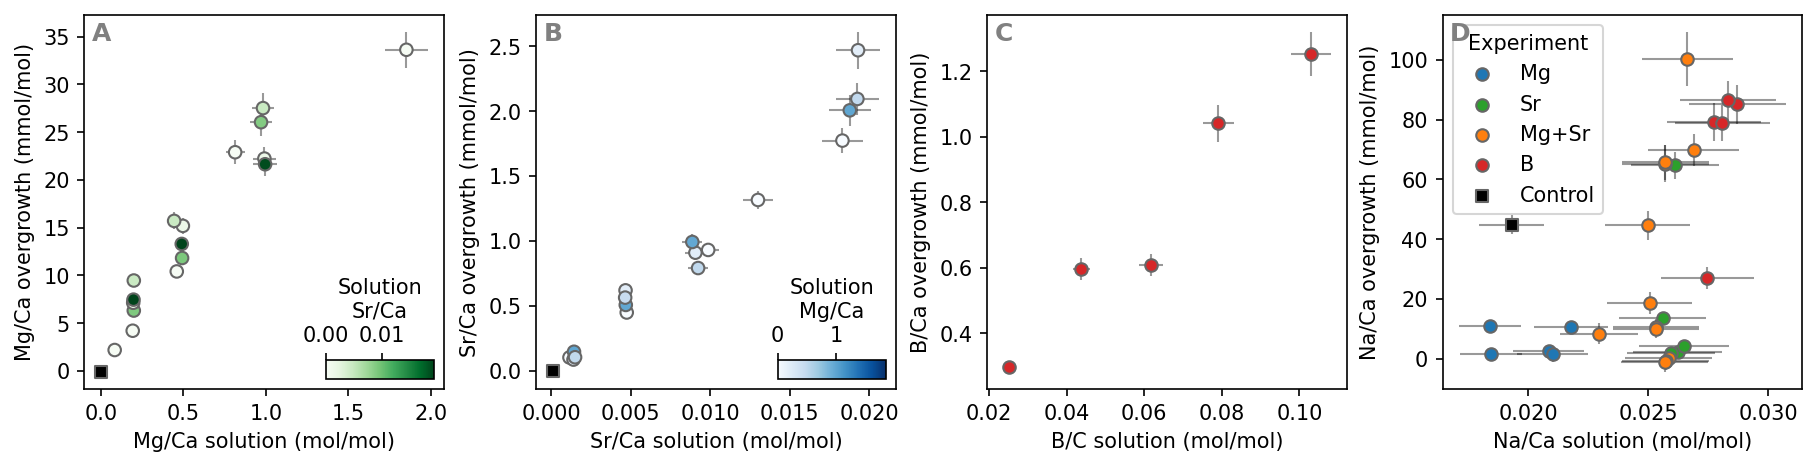

In [14]:
fig, axs = vplt.solution_vs_solid(dat.loc[no_high_mg], phase='overgrowth');

vplt.label_axes(axs)

fig.savefig('figs/Fig6.pdf')

### Vaterite composition as a function of solution chemistry

In [39]:
el = 'Mg'
dat.loc[no_high_mg & vaterite_growth & (dat.metadata.Experiment.isin([el]).values)]

Type                calcite                                      \
Quantity               B/Ca            Mg/Ca              Na/Ca   
Instrument             calc             calc               calc   
Unit                    NaN              NaN                NaN   
16          (9.0+/-1.9)e-06  0.0012+/-0.0017  (1.84+/-0.23)e-06   
17          (3.7+/-0.8)e-06    0.003+/-0.004  (2.18+/-0.27)e-06   
18          (6.0+/-1.2)e-06    0.006+/-0.009  (2.09+/-0.26)e-06   
19          (2.4+/-0.5)e-06    0.011+/-0.016  (1.85+/-0.23)e-06   
20          (5.0+/-1.0)e-07      0.03+/-0.04  (2.10+/-0.26)e-06   

Type                                     derived metadata             \
Quantity              Sr/Ca                    f    Batch Experiment   
Instrument             calc                 calc       NA         NA   
Unit                    NaN fractional_abundance       NA         NA   
16          (5.5+/-1.6)e-06        0.393+/-0.006        1         Mg   
17          (5.7+/-1.7)e-06        0.404+/-0.006        1         Mg   
18          (5.8+/-1.7)e-06        0.366+/-0.006        1         Mg   
19          (6.8+/-2.0)e-06        0.288+/-0.006        1         Mg   
20          (5.8+/-1.7)e-06        0.243+/-0.006        1         Mg   

Type       overgrowth                              ...   solution_start  \
Quantity         B/Ca        D_B             D_Mg  ...            Sr/Ca   
Instrument       calc       calc             calc  ...             calc   
Unit          mol/mol        NaN              NaN  ...          mol/mol   
16          nan+/-nan  nan+/-nan  0.0261+/-0.0023  ...  (7.9+/-0.6)e-05   
17          nan+/-nan  nan+/-nan  0.0218+/-0.0019  ...  (8.1+/-0.6)e-05   
18          nan+/-nan  nan+/-nan  0.0226+/-0.0020  ...  (8.3+/-0.6)e-05   
19          nan+/-nan  nan+/-nan  0.0281+/-0.0025  ...  (9.6+/-0.7)e-05   
20          nan+/-nan  nan+/-nan  0.0182+/-0.0016  ...  (8.2+/-0.6)e-05   

Type                             vaterite                            \
Quantity                pH_NBS       B/Ca        D_B           D_Mg   
Instrument           electrode       calc       calc           calc   
Unit       Unnamed: 29_level_3    mol/mol        NaN            NaN   
16                       8.209  nan+/-nan  nan+/-nan  0.035+/-0.016   
17                       8.193  nan+/-nan  nan+/-nan  0.027+/-0.014   
18                       8.200  nan+/-nan  nan+/-nan  0.031+/-0.019   
19                       8.198  nan+/-nan  nan+/-nan    0.06+/-0.05   
20                       8.209  nan+/-nan  nan+/-nan  0.022+/-0.018   

Type                                                                     \
Quantity           D_Na          D_Sr            Mg/Ca            Na/Ca   
Instrument         calc          calc             calc             calc   
Unit                NaN           NaN          mol/mol          mol/mol   
16          1.05+/-0.18  -0.22+/-0.13  0.0030+/-0.0013  0.0194+/-0.0030   
17          0.83+/-0.14  -0.15+/-0.11  0.0053+/-0.0027  0.0180+/-0.0027   
18          0.24+/-0.14  -0.16+/-0.15    0.014+/-0.009  0.0049+/-0.0029   
19            0.3+/-0.4  -0.70+/-0.32      0.05+/-0.04    0.005+/-0.007   
20          0.15+/-0.23   0.06+/-0.27    0.040+/-0.033    0.003+/-0.005   

Type                          
Quantity               Sr/Ca  
Instrument              calc  
Unit                 mol/mol  
16          (-1.8+/-1.0)e-05  
17          (-1.2+/-0.9)e-05  
18          (-1.3+/-1.2)e-05  
19          (-6.7+/-3.1)e-05  
20           (0.5+/-2.2)e-05  

[5 rows x 61 columns]

/usr/lib/python3.10/site-packages/matplotlib/axes/_base.py:2539: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)


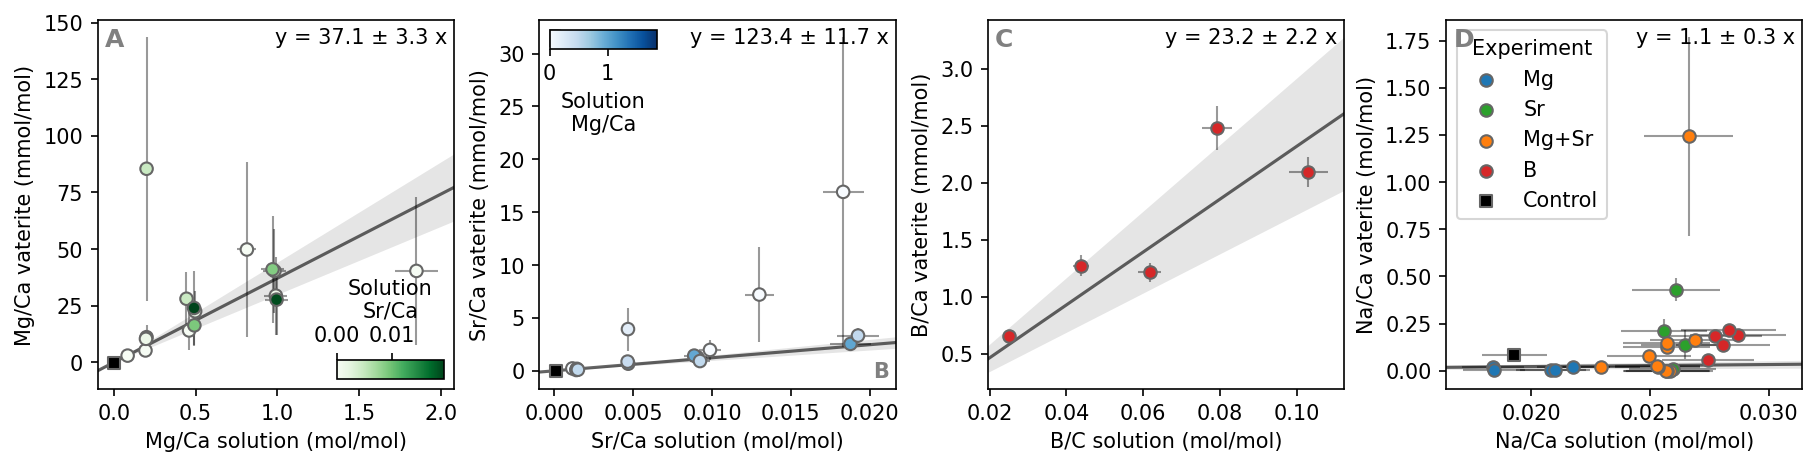

In [86]:
fig, axs = vplt.solution_vs_solid(dat=dat.loc[no_high_mg & vaterite_growth], phase='vaterite', vars=['Mg/Ca', 'Sr/Ca', 'B/C', 'Na/Ca'])

def calc_D(x, D):
    return x * D

# line of best fit for single-element experiments
for i, el in enumerate(['Mg', 'Sr', 'B', 'Na']):
    denom = 'Ca'
    if el == 'B':
        denom = 'C'
    yvar = ('vaterite', f'{el}/Ca')
    ax = axs[i]
    ind = no_high_mg & vaterite_growth & (dat.metadata.Experiment.NA.NA.str.contains(el).values.reshape(-1,1))
    m = 1e3
    if el == 'Na':
        ind = no_high_mg & vaterite_growth
        m = 1
    sub = dat.loc[ind]
    x = nom(sub.solution_start[f'{el}/{denom}']).ravel()
    y = nom(sub[yvar]).ravel() * m
    yerr = std(sub[yvar]).ravel() * m
    
    # ax.scatter(x, y, color=(0,0,0,0), edgecolor='k', lw=1)
    
    p, cov = optimize.curve_fit(calc_D, x, y, sigma=yerr)
    # p, cov = np.polyfit(x, y, 1, cov=True)
    up = un.correlated_values(p, cov)
    ax.set_xlim(ax.get_xlim())
    nx = np.linspace(*ax.get_xlim())
    # pred = np.polyval(up, nx)
    pred = calc_D(nx, up)
    ci_m = stats.t.interval(0.95, len(x) - 1)
    ax.plot(nx, nom(pred), color='k', alpha=0.6, zorder=-5)
    ax.fill_between(nx, nom(pred) + std(pred) * ci_m[0], nom(pred) + std(pred) * ci_m[1], alpha=0.1, color='k', lw=0, zorder=-5)
    ax.text(0.98, 0.98, f'y = {nom(up).item():.1f} ± {std(up).item():.1f} x', ha='right', va='top', transform=ax.transAxes)

vplt.label_axes(axs)
axs[1].text(0.98, 0.02, 'B', color='grey', ha='right', va='bottom', weight='bold', fontsize=10, transform=axs[1].transAxes)

fig.savefig('figs/Fig12.pdf')

Add on partition coefficients from these lines.

### Overgrowth vs. vaterite composition

/usr/lib/python3.10/site-packages/matplotlib/axes/_base.py:2539: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)


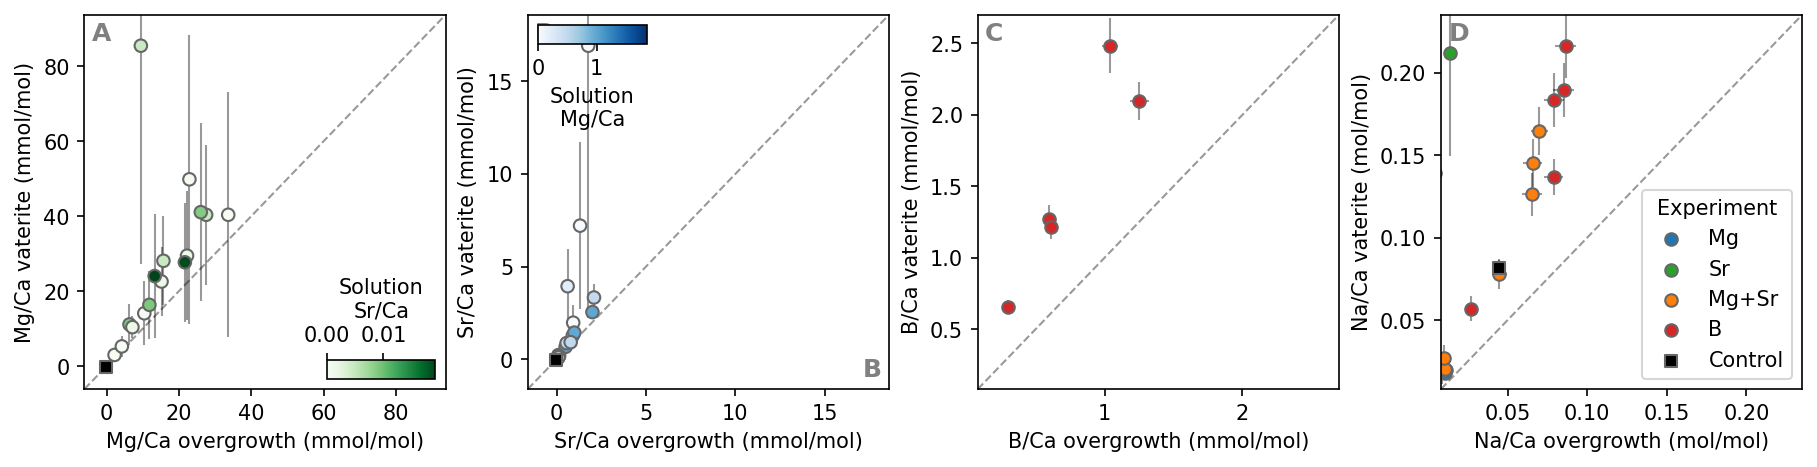

In [20]:
fig, axs = vplt.solid_vs_solid(dat=dat.loc[no_high_mg & vaterite_growth], xphase='overgrowth', yphase='vaterite', vars=['Mg/Ca', 'Sr/Ca', 'B/Ca', 'Na/Ca']);

vplt.label_axes(axs)
axs[1].text(0.98, 0.02, 'B', color='grey', ha='right', va='bottom', weight='bold', fontsize=12, transform=axs[1].transAxes)

fig.savefig('figs/Fig13a.pdf')

### Calcite vs. vaterite composition

/usr/lib/python3.10/site-packages/matplotlib/axes/_base.py:2539: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)


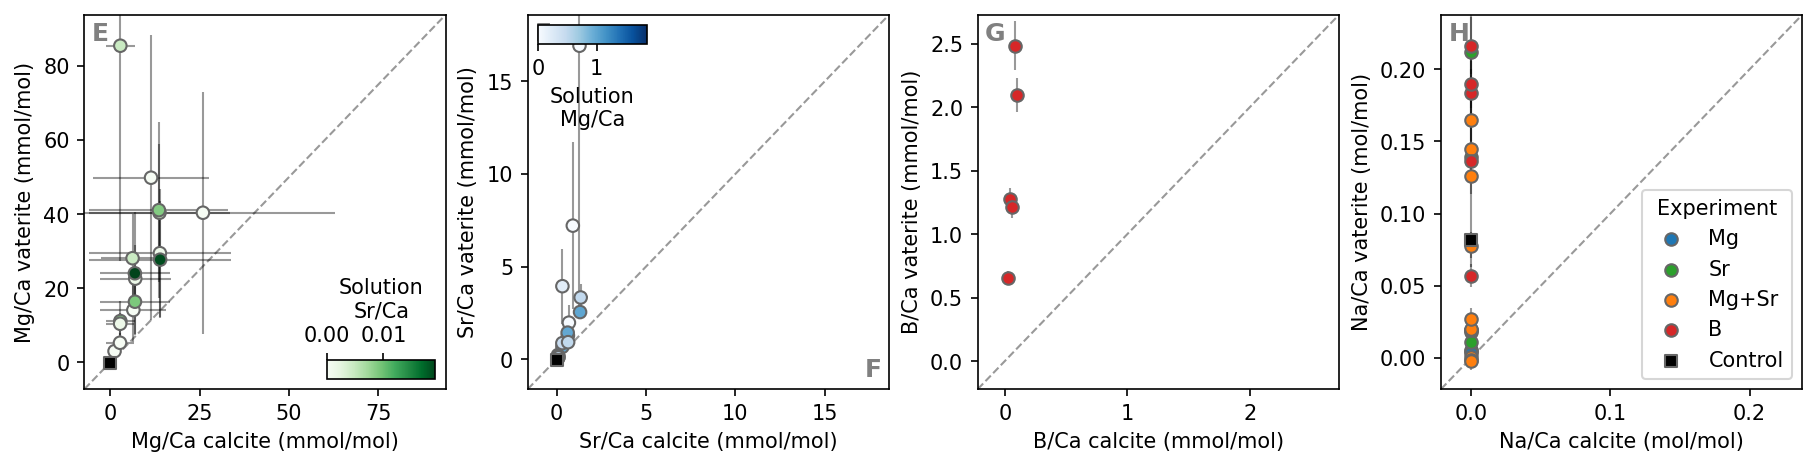

In [36]:
fig, axs = vplt.solid_vs_solid(dat=dat.loc[no_high_mg & vaterite_growth], xphase='calcite', yphase='vaterite', vars=['Mg/Ca', 'Sr/Ca', 'B/Ca', 'Na/Ca']);

vplt.label_axes(axs, labels='EFGH')
axs[1].text(0.98, 0.02, 'F', color='grey', ha='right', va='bottom', weight='bold', fontsize=12, transform=axs[1].transAxes)


fig.savefig('figs/Fig13b.pdf')